# 03 — Calibration-weight sweep
Mirror the source paper's central sensitivity experiment: vary the calibration weight and measure calibration against predictive quality. Select weights on validation data only in confirmatory work.

In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
from innovcal.ca_rnn import TrainingConfig
from innovcal.data import simulate_multivariate_series
from innovcal.experiments.comparison import lambda_sweep
OUT = ROOT / 'results' / 'lambda_sweep'; OUT.mkdir(parents=True, exist_ok=True)

In [2]:
values = simulate_multivariate_series(1200, regime='nonlinear', seed=301)
weights = [0.0, 1.0, 10.0, 50.0, 100.0, 250.0, 500.0]
sweep = lambda_sweep(values, weights, training_config=TrainingConfig(epochs=150, patience=20, seed=301))
display(sweep)
sweep.to_csv(OUT / 'lambda_sweep.csv', index=False)

,lambda_cal,best_epoch,nll,rmse,energy_score,coverage,interval_width,interval_score,pit_calibration_error,pit_mean_absolute_autocorrelation,pit_mean_ks,coordinate_pit_calibration_error,coordinate_pit_mean_absolute_autocorrelation,coordinate_pit_mean_ks
0,0.0,37,5.310534,0.961703,1.261697,0.896875,3.105629,4.007428,0.001125,0.063224,0.066007,0.001259,0.051463,0.062606
1,1.0,37,5.310748,0.961783,1.261764,0.896875,3.107423,4.007801,0.001117,0.063558,0.065536,0.001240,0.051664,0.061964
2,10.0,39,5.315819,0.963011,1.263115,0.898958,3.118044,4.013519,0.001032,0.066484,0.065405,0.001131,0.053395,0.059687
3,50.0,47,5.337861,0.967926,1.268927,0.904167,3.144551,4.038684,0.000837,0.076279,0.060493,0.000939,0.060640,0.056393
4,100.0,57,5.360485,0.972447,1.274570,0.900000,3.156696,4.065018,0.000638,0.082072,0.055966,0.000751,0.065600,0.056231
5,250.0,60,5.386217,0.977520,1.281344,0.902083,3.190170,4.094580,0.000440,0.084749,0.050166,0.000575,0.067619,0.056181
6,500.0,57,5.409811,0.977022,1.282314,0.907292,3.231730,4.073591,0.000448,0.072882,0.050945,0.000472,0.063353,0.054647


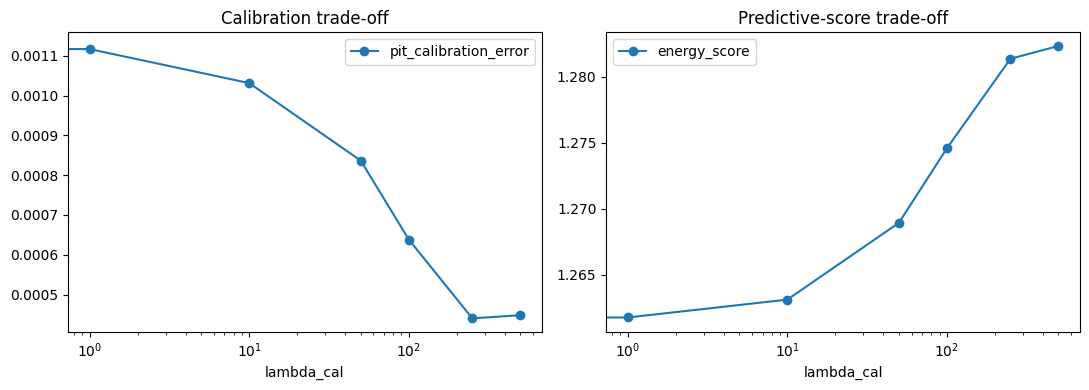

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sweep.plot(x='lambda_cal', y='pit_calibration_error', marker='o', logx=True, ax=axes[0])
sweep.plot(x='lambda_cal', y='energy_score', marker='o', logx=True, ax=axes[1])
axes[0].set_title('Calibration trade-off'); axes[1].set_title('Predictive-score trade-off')
plt.tight_layout()